# 🦷 Fine-tune MedGemma for Dental Diagnostics

This notebook fine-tunes **[MedGemma 1.5 4B IT](https://huggingface.co/google/medgemma-1.5-4b-it)** on dental X-ray analysis using the **[DentalGemma](https://huggingface.co/datasets/naazimsnh02/dentalgemma-vqa)** datasets — a novel domain adaptation since MedGemma was **not** trained on dental data.

**Fine-tuning approach:**
- **LoRA with full bfloat16 precision** for optimal training quality
- **TRL SFTTrainer** for supervised fine-tuning
- Two-stage training: multimodal VQA (image + text) → text-only clinical instruct data

**Datasets:**
- [`naazimsnh02/dentalgemma-vqa`](https://huggingface.co/datasets/naazimsnh02/dentalgemma-vqa) — 1,654 dental X-ray VQA pairs
- [`naazimsnh02/dentalgemma-instruct`](https://huggingface.co/datasets/naazimsnh02/dentalgemma-instruct) — 2,494 clinical dental cases

**Built for the [MedGemma Impact Challenge](https://kaggle.com/competitions/med-gemma-impact-challenge).**

## Setup

**Requirements:** A GPU with bfloat16 support and ≥40 GB VRAM (e.g., A100).

**Google Colab:**
1. Click **▾ (Additional connection options)** → **Change runtime type**
2. Select **A100 GPU** under Hardware accelerator

### Get access to MedGemma

1. Create a [Hugging Face account](https://huggingface.co/join) if you don't have one
2. Accept usage conditions at [google/medgemma-1.5-4b-it](https://huggingface.co/google/medgemma-1.5-4b-it)

### Configure your HF token

Generate a Hugging Face **write** access token at [settings/tokens](https://huggingface.co/settings/tokens).

**Google Colab:** Add your token to the 🔑 Secrets tab as `HF_TOKEN`.

In [1]:
import os
import sys

if "google.colab" in sys.modules and not os.environ.get("VERTEX_PRODUCT"):
    from google.colab import userdata
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
else:
    if os.environ.get("VERTEX_PRODUCT") == "COLAB_ENTERPRISE":
        os.environ["HF_HOME"] = "/content/hf"
    from huggingface_hub import get_token
    if get_token() is None:
        from huggingface_hub import notebook_login
        notebook_login()

In [2]:
import os
from huggingface_hub import get_token

# 1. Check if the env var is injected
if "HF_TOKEN" in os.environ:
    print("✅ Success! 'HF_TOKEN' environment variable is present.")
    print(f"Token starts with: {os.environ['HF_TOKEN'][:4]}****")
else:
    print("❌ 'HF_TOKEN' environment variable is MISSING.")

# 2. Check what Hugging Face sees
token = get_token()
if token:
    print(f"✅ Hugging Face Login Status: Authenticated (Token found)")
else:
    print("❌ Hugging Face Login Status: Not Logged In")

✅ Success! 'HF_TOKEN' environment variable is present.
Token starts with: hf_u****
✅ Hugging Face Login Status: Authenticated (Token found)


### Install dependencies

In [3]:
# Uninstall incompatible PyTorch and torchvision versions
%uv pip uninstall torch torchvision torchaudio

Using Python 3.12.6 environment at: /usr/local
Uninstalled 3 packages in 943ms
 - torch==2.8.0+cu129
 - torchaudio==2.8.0+cu129
 - torchvision==0.23.0+cu129
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Install compatible PyTorch and torchvision versions
%uv pip install torch==2.9.0+cu128 torchvision==0.24.0+cu128 --index-url https://download.pytorch.org/whl/cu128

Using Python 3.12.6 environment at: /usr/local
Resolved 29 packages in 2.01s
⠙ Preparing packages... (0/16)
⠙ Preparing packages... (0/16)
⠙ Preparing packages... (0/16)
torchvision ------------------------------     0 B/7.68 MiB
⠙ Preparing packages... (0/16)
torchvision ------------------------------ 8.00 KiB/7.68 MiB
⠙ Preparing packages... (0/16)
torchvision ------------------------------ 8.00 KiB/7.68 MiB
⠙ Preparing packages... (0/16)
torchvision ------------------------------ 8.00 KiB/7.68 MiB
⠙ Preparing packages... (0/16)
torchvision ------------------------------ 8.00 KiB/7.68 MiB
⠙ Preparing packages... (0/16)
torchvision ------------------------------ 8.00 KiB/7.68 MiB
⠙ Preparing packages... (0/16)
torchvision ------------------------------ 8.00 KiB/7.68 MiB
⠙ Preparing packages... (0/16)
torchvision ------------------------------ 8.00 KiB/7.68 MiB
⠙ Preparing packages... (0/16)
torchvision ------------------------------ 8.00 KiB/7.68 MiB
⠙ Preparing packages... (0/16)
tor

In [1]:
    # Install other dependencies
    %uv pip install accelerate bitsandbytes datasets evaluate peft tensorboard transformers trl

Using Python 3.12.6 environment at: /usr/local
Resolved 86 packages in 333ms
⠙ Preparing packages... (0/16)
⠙ Preparing packages... (0/16)
⠙ Preparing packages... (0/16)
annotated-doc ------------------------------     0 B/5.18 KiB
⠙ Preparing packages... (0/16)
annotated-doc ------------------------------ 5.18 KiB/5.18 KiB
⠙ Preparing packages... (0/16)
typer-slim ------------------------------     0 B/3.31 KiB
annotated-doc ------------------------------ 5.18 KiB/5.18 KiB
⠙ Preparing packages... (0/16)
typer-slim ------------------------------ 3.31 KiB/3.31 KiB
annotated-doc ------------------------------ 5.18 KiB/5.18 KiB
⠙ Preparing packages... (0/16)
typer-slim ------------------------------ 3.31 KiB/3.31 KiB
annotated-doc ------------------------------ 5.18 KiB/5.18 KiB
typer      ------------------------------ 14.86 KiB/55.12 KiB
⠙ Preparing packages... (0/16)
typer-slim ------------------------------ 3.31 KiB/3.31 KiB
annotated-doc ------------------------------ 5.18 KiB/5.18 K

In [1]:
# Verify correct Pytorch version
import torch
print(f"PyTorch: {torch.__version__}")  # Should show 2.9.0+cu128, NOT 2.10.0

PyTorch: 2.9.0+cu128


## Load DentalGemma Datasets

We use two purpose-built datasets from HuggingFace Hub:

| Dataset | Type | Samples | Tasks |
|:--------|:-----|--------:|:------|
| `dentalgemma-vqa` | Multimodal (image + text) | 2,529 | Cavity detection, OPG classification, localized pathology detection |
| `dentalgemma-instruct` | Text-only | 2,494 | Clinical case assessment, treatment planning, patient counseling |

Both datasets are pre-formatted in chat template format (system/user/assistant) compatible with MedGemma's expected input.

In [2]:
from datasets import load_dataset

vqa_data = load_dataset("naazimsnh02/dentalgemma-vqa")
instruct_data = load_dataset("naazimsnh02/dentalgemma-instruct")

print("=" * 50)
print("DentalGemma VQA (Multimodal):")
print(vqa_data)
print("\nDentalGemma Instruct (Text-only):")
print(instruct_data)

README.md:   0%|          | 0.00/2.66k [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/359M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/397M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/339M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/116M [00:00<?, ?B/s]

...

data/train-00000-of-00001.parquet:   0%|          | 0.00/863k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/105k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2244 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/250 [00:00<?, ? examples/s]

DentalGemma VQA (Multimodal):
DatasetDict({
    train: Dataset({
        features: ['image', 'messages', 'source', 'condition'],
        num_rows: 2276
    })
    validation: Dataset({
        features: ['image', 'messages', 'source', 'condition'],
        num_rows: 253
    })
})

DentalGemma Instruct (Text-only):
DatasetDict({
    train: Dataset({
        features: ['messages', 'source', 'condition'],
        num_rows: 2244
    })
    validation: Dataset({
        features: ['messages', 'source', 'condition'],
        num_rows: 250
    })
})


### Inspect VQA samples

Each VQA sample contains:
- `image`: dental X-ray as a PIL Image
- `messages`: JSON string with chat-format messages (system/user[image+text]/assistant)
- `source`: origin dataset tag
- `condition`: dental condition label

In [3]:
import json
from collections import Counter

sample = vqa_data["train"][0]
print("Image size:", sample["image"].size)
print("Source:", sample["source"])
print("Condition:", sample["condition"])
print("\nMessages:")
messages = json.loads(sample["messages"])
for msg in messages:
    role = msg["role"]
    if isinstance(msg["content"], list):
        types = [c["type"] for c in msg["content"]]
        print(f"  {role}: [{', '.join(types)}]")
    else:
        print(f"  {role}: {msg['content'][:120]}...")

print("\n--- Source distribution (train) ---")
for src, cnt in sorted(Counter(vqa_data["train"]["source"]).items()):
    print(f"  {src}: {cnt}")

Image size: (271, 186)
Source: dental_cavity_detection
Condition: decay

Messages:
  system: You are an expert dental clinician and radiologist AI assistant. Analyze dental images and clinical information to provi...
  user: [image, text]
  assistant: Severe and extensive decay is evident requiring urgent comprehensive treatment. Multiple teeth are significantly affecte...

--- Source distribution (train) ---
  dental_cavity_detection: 585
  dental_opg_classification: 1092
  opg_object_detection: 482
  panoramic_dental_xray: 117


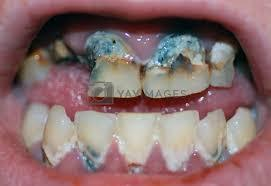

In [4]:
# Display a sample dental X-ray
vqa_data["train"][0]["image"]

In [5]:
# Display a sample dental X-ray details
vqa_data["train"][0]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=271x186>,
 'messages': '[{"role": "system", "content": "You are an expert dental clinician and radiologist AI assistant. Analyze dental images and clinical information to provide accurate, evidence-based assessments. Always recommend clinical correlation and professional evaluation for definitive diagnosis."}, {"role": "user", "content": [{"type": "image"}, {"type": "text", "text": "Evaluate the extent of any dental problems visible in this photograph."}]}, {"role": "assistant", "content": "Severe and extensive decay is evident requiring urgent comprehensive treatment. Multiple teeth are significantly affected, and referral for comprehensive restorative care is strongly recommended. This intraoral photograph demonstrates visible signs of dental decay with discoloration and surface breakdown. Advanced changes are noted, suggesting severe and extensive pathology. Patient education on oral hygiene may help prevent further deca

### Inspect instruct samples

In [6]:
sample = instruct_data["train"][0]
print("Source:", sample["source"])
print("Condition:", sample["condition"])
print("\nMessages:")
messages = json.loads(sample["messages"])
for msg in messages:
    print(f"  {msg['role']}: {str(msg['content'])[:150]}...")

print(f"\nUnique conditions: {len(set(instruct_data['train']['condition']))}")

Source: wildstash_dental_instruct
Condition: Suspicious oral mucosal lesion requiring biopsy

Messages:
  system: You are an expert dental clinician providing comprehensive patient care. Always consider the patient's full clinical context, medical history, and pro...
  user: Please evaluate this dental patient:

PATIENT: Suspicious oral mucosal lesion requiring biopsy
AGE: 60 years old
SEX: female
OCCUPATION: consultant

C...
  assistant: ## Patient Assessment



**Diagnosis:** Suspicious oral mucosal lesion requiring biopsy
**Etiology:** neoplastic_suspicious
**Urgency:** Urgent (2)

#...

Unique conditions: 92


### Format datasets for training

Parse the JSON `messages` field into Python objects for the chat template collator. The VQA dataset has multimodal message format (image + text); the instruct dataset has text-only messages.

**Note:** MedGemma 1.5 expects system content as `[{"type": "text", "text": "..."}]` list format (see the [official quick start notebook](https://github.com/google-health/medgemma)). We normalize our stored string-format system messages to match.

In [7]:
import json
from typing import Any


def _normalize_messages(messages: list[dict]) -> list[dict]:
    """Ensure system content uses the list-of-dicts format MedGemma expects.

    MedGemma 1.5 chat template expects:
      {"role": "system", "content": [{"type": "text", "text": "..."}]}
    Our datasets store system content as a plain string.
    """
    normalized = []
    for msg in messages:
        if msg["role"] == "system" and isinstance(msg["content"], str):
            normalized.append({
                "role": "system",
                "content": [{"type": "text", "text": msg["content"]}],
            })
        elif msg["role"] == "assistant" and isinstance(msg["content"], str):
            normalized.append({
                "role": "assistant",
                "content": [{"type": "text", "text": msg["content"]}],
            })
        else:
            normalized.append(msg)
    return normalized


def parse_vqa_messages(example: dict[str, Any]) -> dict[str, Any]:
    """Parse JSON messages and normalize for MedGemma's chat template."""
    example["messages"] = _normalize_messages(json.loads(example["messages"]))
    return example


def parse_instruct_messages(example: dict[str, Any]) -> dict[str, Any]:
    """Parse JSON messages and normalize for MedGemma's chat template.

    Instruct messages are text-only, so user content is wrapped in
    [{"type": "text", "text": "..."}] to match the expected format.
    """
    raw = json.loads(example["messages"])
    normalized = []
    for msg in raw:
        if isinstance(msg["content"], str):
            normalized.append({
                "role": msg["role"],
                "content": [{"type": "text", "text": msg["content"]}],
            })
        else:
            normalized.append(msg)
    example["messages"] = normalized
    return example


vqa_data = vqa_data.map(parse_vqa_messages)
instruct_data = instruct_data.map(parse_instruct_messages)

print("VQA train sample messages (parsed):")
sample_msgs = vqa_data['train'][0]['messages']
for m in sample_msgs:
    if isinstance(m['content'], list):
        print(f"  {m['role']}: [{', '.join(c['type'] for c in m['content'])}]")
    else:
        print(f"  {m['role']}: {str(m['content'])[:80]}...")

print(f"\nInstruct train sample messages (parsed):")
sample_msgs = instruct_data['train'][0]['messages']
for m in sample_msgs:
    if isinstance(m['content'], list):
        print(f"  {m['role']}: [{', '.join(c['type'] for c in m['content'])}]")
    else:
        print(f"  {m['role']}: {str(m['content'])[:80]}...")

Map:   0%|          | 0/2276 [00:00<?, ? examples/s]

Map:   0%|          | 0/253 [00:00<?, ? examples/s]

Map:   0%|          | 0/2244 [00:00<?, ? examples/s]

Map:   0%|          | 0/250 [00:00<?, ? examples/s]

VQA train sample messages (parsed):
  system: [text]
  user: [image, text]
  assistant: [text]

Instruct train sample messages (parsed):
  system: [text]
  user: [text]
  assistant: [text]


## Fine-tune with LoRA

We use Low-Rank Adaptation (LoRA) to fine-tune MedGemma efficiently:

- **Full bfloat16 precision** — no quantization for maximum training quality
- **LoRA adapters** (rank 64, alpha 64) attached to attention and MLP layers
- **Only adapter parameters are updated** — the base model stays frozen

This allows fine-tuning a 4B parameter model on a single A100 GPU.

### Load MedGemma full model

In [8]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

model_id = "google/medgemma-1.5-4b-it"

# Check for A100/H100/Ampere or newer for best performance with bfloat16
if torch.cuda.get_device_capability()[0] < 8:
    print("Warning: GPU capabilities < 8. bfloat16 might not be supported or slow.")
else:
    print("High-performance GPU detected (Ampere+). Using native bfloat16.")

# Load Full Model in bfloat16 (No Quantization)
model_kwargs = dict(
    attn_implementation="eager",
    torch_dtype=torch.bfloat16,
    device_map="auto",
)


model = AutoModelForImageTextToText.from_pretrained(model_id, **model_kwargs)
processor = AutoProcessor.from_pretrained(model_id)
processor.tokenizer.padding_side = "right"

print(f"Model loaded: {model_id}")
print(f"Precision: Full bfloat16 (No Quantization)")

High-performance GPU detected (Ampere+). Using native bfloat16.


config.json:   0%|          | 0.00/2.55k [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

Model loaded: google/medgemma-1.5-4b-it
Precision: Full bfloat16 (No Quantization)


### Configure LoRA

In [9]:
from peft import LoraConfig

peft_config = LoraConfig(
    lora_alpha=64,
    lora_dropout=0.05,
    r=64,
    bias="none",
    target_modules="all-linear",
    task_type="CAUSAL_LM",
    modules_to_save=[
        "lm_head",
        "embed_tokens",
    ],
)

### Data collators

We define separate collators for the multimodal VQA data (with images) and the text-only instruct data. Both use `processor.apply_chat_template` to format messages into the model's expected input format.

In [10]:
from typing import Any
import torch

# Enable padding to prevent aspect ratio distortion
if hasattr(processor, "image_processor"):
    if hasattr(processor.image_processor, "do_pad"):
        processor.image_processor.do_pad = True
        print("Enabled padding for image processor.")
    else:
        print("Warning: do_pad not found in image_processor config")

def vqa_collate_fn(examples: list[dict[str, Any]]):
    """Collator for multimodal VQA examples (image + text)."""
    texts = []
    images = []
    for example in examples:
        images.append([example["image"].convert("RGB")])
        texts.append(processor.apply_chat_template(
            example["messages"], add_generation_prompt=False, tokenize=False
        ).strip())

    batch = processor(text=texts, images=images, return_tensors="pt", padding=True)

    # Initialize labels with -100 (masked)
    labels = torch.full_like(batch["input_ids"], -100)
    
    # Iterate through batch to mask user prompts
    for i in range(len(batch["input_ids"])):
        input_ids = batch["input_ids"][i]
        input_list = input_ids.tolist()
        
        # Find start of assistant turn: <start_of_turn>model
        # Tokens: 105 (start_of_turn), 4368 (model)
        start_idx = -1
        for j in range(len(input_list) - 1):
            if input_list[j] == 105 and input_list[j+1] == 4368:
                start_idx = j + 2
                break
        
        if start_idx != -1:
            # Skip potential newline (107)
            if start_idx < len(input_list) and input_list[start_idx] == 107:
                start_idx += 1
            
            # Unmask response
            labels[i, start_idx:] = input_ids[start_idx:]

    # Ensure padding is ignored
    labels[batch["input_ids"] == processor.tokenizer.pad_token_id] = -100

    batch["labels"] = labels
    return batch


def instruct_collate_fn(examples: list[dict[str, Any]]):
    """Collator for text-only instruct examples."""
    texts = []
    for example in examples:
        texts.append(processor.apply_chat_template(
            example["messages"], add_generation_prompt=False, tokenize=False
        ).strip())

    batch = processor.tokenizer(
        texts, return_tensors="pt", padding=True, truncation=True, max_length=1024
    )

    labels = torch.full_like(batch["input_ids"], -100)
    
    for i in range(len(batch["input_ids"])):
        input_ids = batch["input_ids"][i]
        input_list = input_ids.tolist()
        
        start_idx = -1
        for j in range(len(input_list) - 1):
            if input_list[j] == 105 and input_list[j+1] == 4368:
                start_idx = j + 2
                break
        
        if start_idx != -1:
            if start_idx < len(input_list) and input_list[start_idx] == 107:
                start_idx += 1
            labels[i, start_idx:] = input_ids[start_idx:]

    labels[batch["input_ids"] == processor.tokenizer.pad_token_id] = -100
    batch["labels"] = labels
    
    # Add token_type_ids for Gemma3 training
    if "token_type_ids" not in batch:
        batch["token_type_ids"] = torch.zeros_like(batch["input_ids"])
    
    return batch

Enabled padding for image processor.


## Stage 1: Fine-tune on VQA Dataset (Multimodal)

First, we train on the multimodal VQA dataset containing dental X-ray images paired with clinical questions and answers. This teaches the model to:
- Detect cavities and count regions in intraoral X-rays
- Classify dental pathologies from panoramic X-rays (6 classes)
- Identify and count tooth types from panoramic radiographs
- Perform systematic radiographic assessments

**Checkpointing:** Model checkpoints are saved every 100 steps and at each epoch to prevent data loss during long training runs.

In [11]:
def verify_template_and_config():
    """Verification of chat template."""
    print("\n--- Verifying Chat Template ---")
    messages = [
        {"role": "user", "content": "Hello"},
        {"role": "model", "content": "Hi there"}
    ]
    prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    print("Template Output:")
    print(prompt)
    
    tokens = processor.tokenizer.encode(prompt, add_special_tokens=False)
    decoded = [processor.tokenizer.decode([t]) for t in tokens]
    print(f"\nTokens: {tokens}")
    print(f"Decoded: {decoded}")
    
    # Verify key tokens for label masking
    print("\n--- Key Token IDs for Label Masking ---")
    print(f"<start_of_turn>: {processor.tokenizer.encode('<start_of_turn>', add_special_tokens=False)}")
    print(f"'model': {processor.tokenizer.encode('model', add_special_tokens=False)}")
    print(f"Newline: {processor.tokenizer.encode(chr(10), add_special_tokens=False)}")
    
    # These should match the hardcoded values in vqa_collate_fn
    start_of_turn_id = processor.tokenizer.encode('<start_of_turn>', add_special_tokens=False)[0]
    model_id = processor.tokenizer.encode('model', add_special_tokens=False)[0]
    
    if start_of_turn_id == 105 and model_id == 4368:
        print("\n✅ Token IDs match collator expectations (105, 4368)")
    else:
        print(f"\n⚠️ WARNING: Token IDs don't match!")
        print(f"   Expected: 105, 4368")
        print(f"   Got: {start_of_turn_id}, {model_id}")
        print(f"   Update vqa_collate_fn with correct IDs!")
    
    print("\n✅ Verification Complete.")

verify_template_and_config()



--- Verifying Chat Template ---
Template Output:
<bos><start_of_turn>user
Hello<end_of_turn>
<start_of_turn>model
Hi there<end_of_turn>


Tokens: [2, 105, 2364, 107, 9259, 106, 107, 105, 4368, 107, 10979, 993, 106, 107]
Decoded: ['<bos>', '<start_of_turn>', 'user', '\n', 'Hello', '<end_of_turn>', '\n', '<start_of_turn>', 'model', '\n', 'Hi', ' there', '<end_of_turn>', '\n']

--- Key Token IDs for Label Masking ---
<start_of_turn>: [105]
'model': [4368]
Newline: [107]

✅ Token IDs match collator expectations (105, 4368)

✅ Verification Complete.


In [12]:
from trl import SFTConfig

output_dir = "dentalgemma-1.5-4b-it-vqa"  # @param {type: "string"}
num_train_epochs = 5  # @param {type: "number"}
learning_rate = 5e-5  # @param {type: "number"}

vqa_training_args = SFTConfig(
    output_dir=output_dir,
    num_train_epochs=num_train_epochs,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True,
    optim="adamw_torch_fused",
    logging_steps=25,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=10,
    eval_strategy="steps",
    eval_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    learning_rate=learning_rate,
    bf16=True,
    max_grad_norm=1.0,
    warmup_ratio=0.1,
    lr_scheduler_type="linear",
    push_to_hub=False,
    report_to="tensorboard",
    gradient_checkpointing_kwargs={"use_reentrant": False},
    dataset_kwargs={"skip_prepare_dataset": True},
    remove_unused_columns=False,
    label_names=["labels"],
)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [13]:
from trl import SFTTrainer

vqa_trainer = SFTTrainer(
    model=model,
    args=vqa_training_args,
    train_dataset=vqa_data["train"],
    eval_dataset=vqa_data["validation"],
    peft_config=peft_config,
    processing_class=processor,
    data_collator=vqa_collate_fn,
)

/usr/local/lib/python3.12/site-packages/peft/tuners/tuners_utils.py:1225: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)
Detected kernel version 4.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


### Train on VQA data

Training resumes automatically from the latest checkpoint if one exists in the output directory.

In [14]:
import os

# Resume from checkpoint if available
vqa_checkpoint = None
if os.path.isdir(output_dir):
    checkpoints = [d for d in os.listdir(output_dir) if d.startswith("checkpoint-")]
    if checkpoints:
        latest = sorted(checkpoints, key=lambda x: int(x.split("-")[1]))[-1]
        vqa_checkpoint = os.path.join(output_dir, latest)
        print(f"Resuming VQA training from: {vqa_checkpoint}")

vqa_trainer.train(resume_from_checkpoint=vqa_checkpoint)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.


Step,Training Loss,Validation Loss
100,1.575642,1.325520
200,0.476311,0.429889
300,0.285412,0.300016
400,0.214314,0.245096
500,0.184617,0.191756
600,0.172902,0.188615
700,0.177035,0.181745
800,0.158699,0.173097
900,0.160879,0.169342
1000,0.161180,0.166586


KeyboardInterrupt: 

In [15]:
import os
from peft import PeftModel

# Load the best checkpoint (step 2100 - lowest val loss: 0.1585)
best_checkpoint = "checkpoint-2100"
best_checkpoint_path = os.path.join(output_dir, best_checkpoint)

if os.path.exists(best_checkpoint_path):
    print(f"✅ Loading best VQA checkpoint: {best_checkpoint}")
    print(f"   Path: {best_checkpoint_path}")
    print(f"   Validation loss: 0.1585 (best)")
    
    # Load the best checkpoint into the trainer's model
    # This replaces the current model with the best one
    vqa_trainer.model.load_adapter(best_checkpoint_path, adapter_name="default")
    
    # Save the best checkpoint as the final VQA adapter
    vqa_trainer.save_model()
    print(f"✅ Best VQA adapter saved to: {output_dir}")
    
    # Verify what was saved
    saved_files = os.listdir(output_dir)
    adapter_files = [f for f in saved_files if f.endswith('.safetensors') or f == 'adapter_config.json']
    print(f"✅ Saved adapter files: {adapter_files}")
    
else:
    print(f"❌ Checkpoint not found: {best_checkpoint_path}")
    print("Available checkpoints:")
    checkpoints = [d for d in os.listdir(output_dir) if d.startswith("checkpoint-")]
    for cp in sorted(checkpoints, key=lambda x: int(x.split("-")[1])):
        print(f"  - {cp}")


✅ Loading best VQA checkpoint: checkpoint-2100
   Path: dentalgemma-1.5-4b-it-vqa/checkpoint-2100
   Validation loss: 0.1585 (best)
✅ Best VQA adapter saved to: dentalgemma-1.5-4b-it-vqa
✅ Saved adapter files: ['adapter_model.safetensors', 'adapter_config.json']


## Stage 2: Fine-tune on Instruct Dataset (Text-only)

Next, we continue training on the text-only clinical instruct dataset. This teaches the model structured clinical reasoning:
- Diagnosis from patient history and symptoms
- Treatment planning with management protocols
- Antibiotic considerations
- Follow-up scheduling and patient counseling

The LoRA adapter from Stage 1 is carried forward so the model retains its visual capabilities while gaining clinical text reasoning.

In [16]:
instruct_output_dir = "dentalgemma-1.5-4b-it-instruct"  # @param {type: "string"}

instruct_training_args = SFTConfig(
    output_dir=instruct_output_dir,
    num_train_epochs=5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True,
    optim="adamw_torch_fused",
    logging_steps=25,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=10,
    eval_strategy="steps",
    eval_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    learning_rate=5e-5,
    bf16=True,
    max_grad_norm=1.0,
    warmup_ratio=0.1,
    lr_scheduler_type="linear",
    push_to_hub=False,
    report_to="tensorboard",
    gradient_checkpointing_kwargs={"use_reentrant": False},
    dataset_kwargs={"skip_prepare_dataset": True},
    remove_unused_columns=False,
    label_names=["labels"],
)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [17]:
instruct_trainer = SFTTrainer(
    model=vqa_trainer.model,
    args=instruct_training_args,
    train_dataset=instruct_data["train"],
    eval_dataset=instruct_data["validation"],
    processing_class=processor.tokenizer,
    data_collator=instruct_collate_fn,
)

Detected kernel version 4.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


### Train on instruct data

In [18]:
# Resume from checkpoint if available
instruct_checkpoint = None
if os.path.isdir(instruct_output_dir):
    checkpoints = [d for d in os.listdir(instruct_output_dir) if d.startswith("checkpoint-")]
    if checkpoints:
        latest = sorted(checkpoints, key=lambda x: int(x.split("-")[1]))[-1]
        instruct_checkpoint = os.path.join(instruct_output_dir, latest)
        print(f"Resuming instruct training from: {instruct_checkpoint}")

instruct_trainer.train(resume_from_checkpoint=instruct_checkpoint)

instruct_trainer.save_model()
print(f"Instruct adapter saved to: {instruct_output_dir}")

Step,Training Loss,Validation Loss
100,0.298499,0.211163
200,0.059450,0.044749
300,0.013101,0.033130
400,0.010053,0.029387
500,0.004533,0.022419
600,0.006851,0.022572
700,0.003256,0.024014
800,0.002869,0.024194
900,0.002766,0.026082
1000,0.001883,0.027030


KeyboardInterrupt: 

In [19]:
import os

# Load the best checkpoint (step 500 - lowest val loss: 0.022419)
best_checkpoint = "checkpoint-500"
best_checkpoint_path = os.path.join(instruct_output_dir, best_checkpoint)

if os.path.exists(best_checkpoint_path):
    print(f"✅ Loading best Instruct checkpoint: {best_checkpoint}")
    print(f"   Path: {best_checkpoint_path}")
    print(f"   Validation loss: 0.022419 (best)")
    
    # Load the best checkpoint into the trainer's model
    instruct_trainer.model.load_adapter(best_checkpoint_path, adapter_name="default")
    
    # Save the best checkpoint as the final Instruct adapter
    instruct_trainer.save_model()
    print(f"✅ Best Instruct adapter saved to: {instruct_output_dir}")
    
    # Verify what was saved
    saved_files = os.listdir(instruct_output_dir)
    adapter_files = [f for f in saved_files if f.endswith('.safetensors') or f == 'adapter_config.json']
    print(f"✅ Saved adapter files: {adapter_files}")
    
else:
    print(f"❌ Checkpoint not found: {best_checkpoint_path}")
    print("Available checkpoints:")
    checkpoints = [d for d in os.listdir(instruct_output_dir) if d.startswith("checkpoint-")]
    for cp in sorted(checkpoints, key=lambda x: int(x.split("-")[1])):
        print(f"  - {cp}")


✅ Loading best Instruct checkpoint: checkpoint-500
   Path: dentalgemma-1.5-4b-it-instruct/checkpoint-500
   Validation loss: 0.022419 (best)
✅ Best Instruct adapter saved to: dentalgemma-1.5-4b-it-instruct
✅ Saved adapter files: ['adapter_model.safetensors', 'adapter_config.json']


## Merge LoRA Adapter & Push to Hub

Merge the trained LoRA adapter weights into the base model to create a standalone model that can be used without PEFT, then push the merged model and processor to HuggingFace Hub.

In [20]:
from peft import PeftModel
from transformers import AutoModelForImageTextToText

model_id = "google/medgemma-1.5-4b-it"

# Reload the base model in full precision for merging
print("Loading base model for merge...")
base_model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
print(f"✅ Base model loaded: {model_id}")

# Load the fine-tuned LoRA adapter (best checkpoint-500)
print(f"\nLoading LoRA adapter from: {instruct_output_dir}")
merged_model = PeftModel.from_pretrained(base_model, instruct_output_dir)
print(f"✅ LoRA adapter loaded")

# Merge LoRA weights into the base model
print("\nMerging LoRA adapter into base model...")
merged_model = merged_model.merge_and_unload()
print("✅ Merge complete!")

# Verify merged model
print(f"\n📊 Merged model type: {type(merged_model)}")
print(f"📊 Model device: {next(merged_model.parameters()).device}")
print(f"📊 Model dtype: {next(merged_model.parameters()).dtype}")


Loading base model for merge...


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

✅ Base model loaded: google/medgemma-1.5-4b-it

Loading LoRA adapter from: dentalgemma-1.5-4b-it-instruct


/usr/local/lib/python3.12/site-packages/peft/tuners/tuners_utils.py:1225: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


✅ LoRA adapter loaded

Merging LoRA adapter into base model...
✅ Merge complete!

📊 Merged model type: <class 'transformers.models.gemma3.modeling_gemma3.Gemma3ForConditionalGeneration'>
📊 Model device: cuda:0
📊 Model dtype: torch.bfloat16


In [21]:
# Set your HuggingFace repo ID
hub_repo_id = "naazimsnh02/dentalgemma-1.5-4b-it"  # @param {type: "string"}

print(f"\n🚀 Pushing merged model to: {hub_repo_id}")

try:
    # Push model
    merged_model.push_to_hub(
        hub_repo_id, 
        private=False,
        commit_message="DentalGemma 1.5 4B IT - Fine-tuned on dental VQA and clinical instruct data"
    )
    print(f"✅ Model pushed successfully!")
    
    # Push processor
    processor.push_to_hub(
        hub_repo_id,
        commit_message="Add processor for DentalGemma"
    )
    print(f"✅ Processor pushed successfully!")
    
    print(f"\n🎉 Complete! Model available at:")
    print(f"   https://huggingface.co/{hub_repo_id}")
    
except Exception as e:
    print(f"❌ Error pushing to hub: {e}")
    print("\nTrying to save locally instead...")
    
    # Save locally as backup
    local_output = "dentalgemma-1.5-4b-it-merged"
    merged_model.save_pretrained(local_output)
    processor.save_pretrained(local_output)
    print(f"✅ Model saved locally to: {local_output}")



🚀 Pushing merged model to: naazimsnh02/dentalgemma-1.5-4b-it


README.md:   0%|          | 0.00/14.7k [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

README.md:   0%|          | 0.00/14.6k [00:00<?, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


✅ Processor pushed successfully!

🎉 Complete! Model available at:
   https://huggingface.co/naazimsnh02/dentalgemma-1.5-4b-it



**DentalGemma** — Built for the [MedGemma Impact Challenge](https://kaggle.com/competitions/med-gemma-impact-challenge) 🦷